# Параметрическое исследование архитектур подсетей subnet_u и subnet_f для задачи 3


---

## Схема эксперимента

| Прогон | Фиксировано | Варьируется | Сетка |
|--------|-------------|-------------|-------|
| **A**  | subnet_f = (64, 64) — 2 слоя, 64 нейрона | subnet_u: layers ∈ {1…5}, neurons ∈ {8,16,32,64,128} | 5×5 = 25 запусков |
| **B**  | subnet_u = (64, 64, 64) — 3 слоя, 64 нейрона | subnet_f: layers ∈ {1…5}, neurons ∈ {8,16,32,64,128} | 5×5 = 25 запусков |



In [17]:
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import json
import os
import warnings
from itertools import product

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Импорты — OK')

Импорты — OK


In [18]:
from pinn_module_final import (
    make_consistent_config,
    prepare_config,
    build_solution_grid,
    generate_observations,
    generate_collocation_points,
    generate_boundary_points,
    PINN_Source,
    train_adam,
    train_lbfgs,
    evaluate_model,
    device,
)

print(f'Ядро загружено. Устройство: {device}')

Ядро загружено. Устройство: cuda


In [19]:
import os

OUT_DIR = r"D:\PINN_VKR\arch_analysis_3_15"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
N_LAYERS_LIST  = [1, 2, 3, 4, 5]
N_NEURONS_LIST = [8, 16, 32, 64, 128]


FIXED_F_FOR_A = (64, 64)        
FIXED_U_FOR_B = (64, 64, 64)   

FIXED_EPOCHS = 15_000
PRINT_EVERY  = 5_000
EVAL_EVERY   = 2_500
FIXED_NOISE  = 0.001

TASK_DEF = dict(
    u_exact       = lambda x, t: (x**2 + 0.5*x + 1) * np.exp(-t),
    pde_type      = "heat",
    pde_kwargs    = {"k": 0.2},
    bc_left_type  = "dirichlet",
    bc_right_type = "neumann",
    noise_level   = FIXED_NOISE,
    epochs        = FIXED_EPOCHS,
    print_every   = PRINT_EVERY,
    eval_every    = EVAL_EVERY,
)
TASK_NAME = 'Тест 3: Heat D+N'


CKPT_A = os.path.join(OUT_DIR, 'checkpoint_run_A.json')
CKPT_B = os.path.join(OUT_DIR, 'checkpoint_run_B.json')

combos = list(product(N_LAYERS_LIST, N_NEURONS_LIST))
print(f'Задача:        {TASK_NAME}')
print(f'Сетка:         {len(N_LAYERS_LIST)} слоёв × {len(N_NEURONS_LIST)} нейронов = {len(combos)} комбинаций')
print(f'Прогон A:      варьируется subnet_u, subnet_f = {FIXED_F_FOR_A}')
print(f'Прогон B:      варьируется subnet_f, subnet_u = {FIXED_U_FOR_B}')
print(f'Всего запусков: {len(combos) * 2}')
print(f'Результаты → {OUT_DIR}')

Задача:        Тест 3: Heat D+N
Сетка:         5 слоёв × 5 нейронов = 25 комбинаций
Прогон A:      варьируется subnet_u, subnet_f = (64, 64)
Прогон B:      варьируется subnet_f, subnet_u = (64, 64, 64)
Всего запусков: 50
Результаты → D:\PINN_VKR\arch_analysis_3_15


In [ ]:
def count_params(hidden_layers):
    total = 0
    in_dim = 2
    for h in hidden_layers:
        total += in_dim * h + h  
        in_dim = h
    total += in_dim * 1 + 1       
    return total


def make_hidden(n_layers, n_neurons):
    return tuple([n_neurons] * n_layers)


def arch_label(n_layers, n_neurons):
    return f'L{n_layers}_N{n_neurons}'


def run_one(hidden_u, hidden_f, task_def, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    cfg_raw = make_consistent_config(
        hidden_layers_u = hidden_u,
        hidden_layers_f = hidden_f,
        **task_def,
    )
    cfg = prepare_config(cfg_raw)
    trn = cfg['training']
    dom = cfg['domain']

    x_grid, t_grid, U   = build_solution_grid(cfg)
    x_obs, t_obs, u_obs = generate_observations(x_grid, t_grid, U, cfg)
    x_col, t_col        = generate_collocation_points(cfg)
    boundary             = generate_boundary_points(cfg)

    data = {
        'x_obs': x_obs, 't_obs': t_obs, 'u_obs': u_obs,
        'x_col': x_col, 't_col': t_col, 'boundary': boundary,
    }

    model = PINN_Source(
        hidden_u   = hidden_u,
        hidden_f   = hidden_f,
        activation = trn['activation'],
        x_range    = dom['x_range'],
        t_range    = dom['t_range'],
    ).to(device)

    history, _ = train_adam(model, data, cfg)
    train_lbfgs(model, data, cfg)

    m   = evaluate_model(model, cfg, n_eval=80)
    mf  = m['f']
    mu  = m['u']

    params_u = count_params(hidden_u)
    params_f = count_params(hidden_f)

    return {
        # архитектура
        'hidden_u':   str(hidden_u),
        'hidden_f':   str(hidden_f),
        'params_u':   params_u,
        'params_f':   params_f,
        'params_total': params_u + params_f,
        # метрики f
        'f_l2_rel':    mf['l2_rel'],
        'f_h1_rel':    mf['h1_rel'],
        'f_linf':      mf['linf'],
        'f_mae':       mf['mae'],
        'f_rmse':      mf['rmse'],
        # метрики u
        'u_l2_rel':    mu['l2_rel'],
        'u_h1_rel':    mu['h1_rel'],
        'u_linf':      mu['linf'],
        'u_mae':       mu['mae'],
        'u_rmse':      mu['rmse'],

        'final_loss':  history['loss'][-1] if history['loss'] else None,
    }


def load_checkpoint(path):
    if os.path.isfile(path):
        with open(path) as f:
            data = json.load(f)
        print(f'Чекпоинт загружен: {len(data)} результатов ({path})')
        return data
    print('Чекпоинт не найден, начинаем с нуля.')
    return []


def save_checkpoint(path, data):
    with open(path, 'w') as f:
        json.dump(data, f, indent=2)


print('Вспомогательные функции — OK')
print(f'Всего комбинаций на прогон: {len(combos)}')
print('Примеры архитектур:')
for nl, nn in [(1,8),(3,64),(5,128)]:
    h = make_hidden(nl, nn)
    print(f'  L{nl} N{nn:3d}  →  hidden={h}  params={count_params(h)}')

Вспомогательные функции — OK
Всего комбинаций на прогон: 25
Примеры архитектур:
  L1 N  8  →  hidden=(8,)  params=33
  L3 N 64  →  hidden=(64, 64, 64)  params=8577
  L5 N128  →  hidden=(128, 128, 128, 128, 128)  params=66561


---
##  Прогон A — фиксированная subnet_f = (64, 64), варьируется subnet_u


In [22]:
import time

results_A = load_checkpoint(CKPT_A)
done_A = {r['hidden_u'] for r in results_A}

total_A = len(combos)
run_i   = len(done_A)

print(f'\n{"═"*70}')
print(f'ПРОГОН A  |  subnet_f фиксирована = {FIXED_F_FOR_A}')
print(f'Варьируется subnet_u: {len(N_LAYERS_LIST)} слоёв × {len(N_NEURONS_LIST)} нейронов')
print(f'{"═"*70}\n')

for n_layers, n_neurons in combos:
    hidden_u = make_hidden(n_layers, n_neurons)
    hidden_f = FIXED_F_FOR_A
    key = str(hidden_u)

    if key in done_A:
        print(f'  [пропуск] subnet_u={hidden_u} — уже выполнено')
        continue

    run_i += 1
    lbl = arch_label(n_layers, n_neurons)
    print(f'[A {run_i}/{total_A}]  subnet_u={hidden_u} ({count_params(hidden_u)} пар.)  '
          f'subnet_f={hidden_f}')
    t0 = time.time()

    row = run_one(hidden_u, hidden_f, TASK_DEF, seed=SEED)
    row['run']       = 'A'
    row['n_layers']  = n_layers
    row['n_neurons'] = n_neurons
    row['arch_label']= lbl
    row['varied']    = 'subnet_u'

    results_A.append(row)
    done_A.add(key)
    save_checkpoint(CKPT_A, results_A)

    elapsed = time.time() - t0
    print(f'  → f_L2={row["f_l2_rel"]*100:.3f}%  '
          f'u_L2={row["u_l2_rel"]*100:.3f}%  '
          f'time={elapsed:.0f}s  [ckpt]')

df_A = pd.DataFrame(results_A).sort_values(['n_layers','n_neurons']).reset_index(drop=True)
df_A.to_csv(os.path.join(OUT_DIR, 'run_A_results.csv'), index=False)
print(f'\n✓ Прогон A завершён. {len(df_A)} результатов → run_A_results.csv')

Чекпоинт загружен: 25 результатов (D:\PINN_VKR\arch_analysis_3_15\checkpoint_run_A.json)

══════════════════════════════════════════════════════════════════════
ПРОГОН A  |  subnet_f фиксирована = (64, 64)
Варьируется subnet_u: 5 слоёв × 5 нейронов
══════════════════════════════════════════════════════════════════════

  [пропуск] subnet_u=(8,) — уже выполнено
  [пропуск] subnet_u=(16,) — уже выполнено
  [пропуск] subnet_u=(32,) — уже выполнено
  [пропуск] subnet_u=(64,) — уже выполнено
  [пропуск] subnet_u=(128,) — уже выполнено
  [пропуск] subnet_u=(8, 8) — уже выполнено
  [пропуск] subnet_u=(16, 16) — уже выполнено
  [пропуск] subnet_u=(32, 32) — уже выполнено
  [пропуск] subnet_u=(64, 64) — уже выполнено
  [пропуск] subnet_u=(128, 128) — уже выполнено
  [пропуск] subnet_u=(8, 8, 8) — уже выполнено
  [пропуск] subnet_u=(16, 16, 16) — уже выполнено
  [пропуск] subnet_u=(32, 32, 32) — уже выполнено
  [пропуск] subnet_u=(64, 64, 64) — уже выполнено
  [пропуск] subnet_u=(128, 128, 128) 

---
##  Прогон B — фиксированная subnet_u = (64, 64, 64), варьируется subnet_f


In [23]:
import time
results_B = load_checkpoint(CKPT_B)
done_B = {r['hidden_f'] for r in results_B}

total_B = len(combos)
run_i   = len(done_B)

print(f'\n{"═"*70}')
print(f'ПРОГОН B  |  subnet_u фиксирована = {FIXED_U_FOR_B}')
print(f'Варьируется subnet_f: {len(N_LAYERS_LIST)} слоёв × {len(N_NEURONS_LIST)} нейронов')
print(f'{"═"*70}\n')

for n_layers, n_neurons in combos:
    hidden_f = make_hidden(n_layers, n_neurons)
    hidden_u = FIXED_U_FOR_B
    key = str(hidden_f)

    if key in done_B:
        print(f'  [пропуск] subnet_f={hidden_f} — уже выполнено')
        continue

    run_i += 1
    lbl = arch_label(n_layers, n_neurons)
    print(f'[B {run_i}/{total_B}]  subnet_f={hidden_f} ({count_params(hidden_f)} пар.)  '
          f'subnet_u={hidden_u}')
    t0 = time.time()

    row = run_one(hidden_u, hidden_f, TASK_DEF, seed=SEED)
    row['run']       = 'B'
    row['n_layers']  = n_layers
    row['n_neurons'] = n_neurons
    row['arch_label']= lbl
    row['varied']    = 'subnet_f'

    results_B.append(row)
    done_B.add(key)
    save_checkpoint(CKPT_B, results_B)

    elapsed = time.time() - t0
    print(f'  → f_L2={row["f_l2_rel"]*100:.3f}%  '
          f'u_L2={row["u_l2_rel"]*100:.3f}%  '
          f'time={elapsed:.0f}s  [ckpt]')

df_B = pd.DataFrame(results_B).sort_values(['n_layers','n_neurons']).reset_index(drop=True)
df_B.to_csv(os.path.join(OUT_DIR, 'run_B_results.csv'), index=False)
print(f'\n✓ Прогон B завершён. {len(df_B)} результатов → run_B_results.csv')

Чекпоинт загружен: 25 результатов (D:\PINN_VKR\arch_analysis_3_15\checkpoint_run_B.json)

══════════════════════════════════════════════════════════════════════
ПРОГОН B  |  subnet_u фиксирована = (64, 64, 64)
Варьируется subnet_f: 5 слоёв × 5 нейронов
══════════════════════════════════════════════════════════════════════

  [пропуск] subnet_f=(8,) — уже выполнено
  [пропуск] subnet_f=(16,) — уже выполнено
  [пропуск] subnet_f=(32,) — уже выполнено
  [пропуск] subnet_f=(64,) — уже выполнено
  [пропуск] subnet_f=(128,) — уже выполнено
  [пропуск] subnet_f=(8, 8) — уже выполнено
  [пропуск] subnet_f=(16, 16) — уже выполнено
  [пропуск] subnet_f=(32, 32) — уже выполнено
  [пропуск] subnet_f=(64, 64) — уже выполнено
  [пропуск] subnet_f=(128, 128) — уже выполнено
  [пропуск] subnet_f=(8, 8, 8) — уже выполнено
  [пропуск] subnet_f=(16, 16, 16) — уже выполнено
  [пропуск] subnet_f=(32, 32, 32) — уже выполнено
  [пропуск] subnet_f=(64, 64, 64) — уже выполнено
  [пропуск] subnet_f=(128, 128, 1

---
##  Сводная таблица — Прогон A 

In [ ]:
csv_A = os.path.join(OUT_DIR, 'run_A_results.csv')
if 'df_A' not in dir() or df_A is None:
    df_A = pd.read_csv(csv_A)

def fmt_pct(x): return f'{x*100:.4f}%'

def make_summary_table(df, varied_col):
    cols = [varied_col, 'params_u', 'params_f', 'params_total',
            'f_l2_rel', 'f_h1_rel', 
            'u_l2_rel', 'u_h1_rel', 
            'final_loss']
    tbl = df[cols].copy()
    for c in ['f_l2_rel','f_h1_rel','u_l2_rel','u_h1_rel']:
        tbl[c] = df[c].apply(fmt_pct)
    tbl['final_loss'] = df['final_loss'].apply(lambda x: f'{x:.3e}')

    return tbl.reset_index(drop=True)

print('═'*80)
print('ПРОГОН A — варьируется subnet_u  |  subnet_f зафиксирована:', FIXED_F_FOR_A)
print('═'*80)

tbl_A = make_summary_table(df_A, 'hidden_u')
display(tbl_A)
tbl_A.to_csv(os.path.join(OUT_DIR, 'table_run_A.csv'), index=False)
print('→ table_run_A.csv')

════════════════════════════════════════════════════════════════════════════════
ПРОГОН A — варьируется subnet_u  |  subnet_f зафиксирована: (64, 64)
════════════════════════════════════════════════════════════════════════════════


,hidden_u,params_u,params_f,params_total,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,final_loss
0,"(8,)",33,4417,4450,0.4565%,3.5050%,0.0376%,0.2471%,3.811e-04
1,"(16,)",65,4417,4482,0.7365%,5.8740%,0.0370%,0.2611%,1.639e-04
2,"(32,)",129,4417,4546,0.9741%,8.1161%,0.0425%,0.3322%,1.537e-04
3,"(64,)",257,4417,4674,0.5540%,3.9941%,0.0263%,0.2079%,8.017e-04
4,"(128,)",513,4417,4930,0.8920%,6.6008%,0.0510%,0.4087%,6.745e-04
5,"(8, 8)",105,4417,4522,1.3276%,8.5537%,0.0761%,0.5219%,5.880e-05
6,"(16, 16)",337,4417,4754,1.2443%,10.1950%,0.0792%,0.6219%,2.483e-05
7,"(32, 32)",1185,4417,5602,1.4001%,9.4595%,0.0513%,0.4324%,2.717e-05
8,"(64, 64)",4417,4417,8834,1.6026%,13.2192%,0.0514%,0.4221%,2.071e-04
9,"(128, 128)",17025,4417,21442,1.0618%,8.9710%,0.0430%,0.3982%,1.541e-04


→ table_run_A.csv


##  Сводная таблица — Прогон B 

In [25]:
csv_B = os.path.join(OUT_DIR, 'run_B_results.csv')
if 'df_B' not in dir() or df_B is None:
    df_B = pd.read_csv(csv_B)

print('═'*80)
print('ПРОГОН B — варьируется subnet_f  |  subnet_u зафиксирована:', FIXED_U_FOR_B)
print('═'*80)

tbl_B = make_summary_table(df_B, 'hidden_f')
display(tbl_B)
tbl_B.to_csv(os.path.join(OUT_DIR, 'table_run_B.csv'), index=False)
print('→ table_run_B.csv')

════════════════════════════════════════════════════════════════════════════════
ПРОГОН B — варьируется subnet_f  |  subnet_u зафиксирована: (64, 64, 64)
════════════════════════════════════════════════════════════════════════════════


,hidden_f,params_u,params_f,params_total,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,final_loss
0,"(8,)",8577,33,8610,0.9553%,5.5667%,0.0553%,0.3610%,9.070e-04
1,"(16,)",8577,65,8642,0.8967%,5.8148%,0.0372%,0.2821%,7.017e-04
2,"(32,)",8577,129,8706,1.9125%,8.8760%,0.1027%,0.6263%,8.966e-04
3,"(64,)",8577,257,8834,1.3846%,7.6564%,0.0632%,0.4586%,8.483e-04
4,"(128,)",8577,513,9090,1.4491%,10.2064%,0.0653%,0.4848%,6.847e-04
5,"(8, 8)",8577,105,8682,0.7244%,4.8545%,0.0431%,0.3198%,1.753e-04
6,"(16, 16)",8577,337,8914,0.5092%,3.8767%,0.0307%,0.2667%,2.813e-04
7,"(32, 32)",8577,1185,9762,2.9272%,19.5433%,0.0840%,0.6378%,2.873e-04
8,"(64, 64)",8577,4417,12994,1.9075%,13.8799%,0.0416%,0.3824%,2.829e-04
9,"(128, 128)",8577,17025,25602,1.3477%,8.1017%,0.0622%,0.4749%,5.387e-04


→ table_run_B.csv


---
##  Heatmap: метрики на сетке слои × нейроны

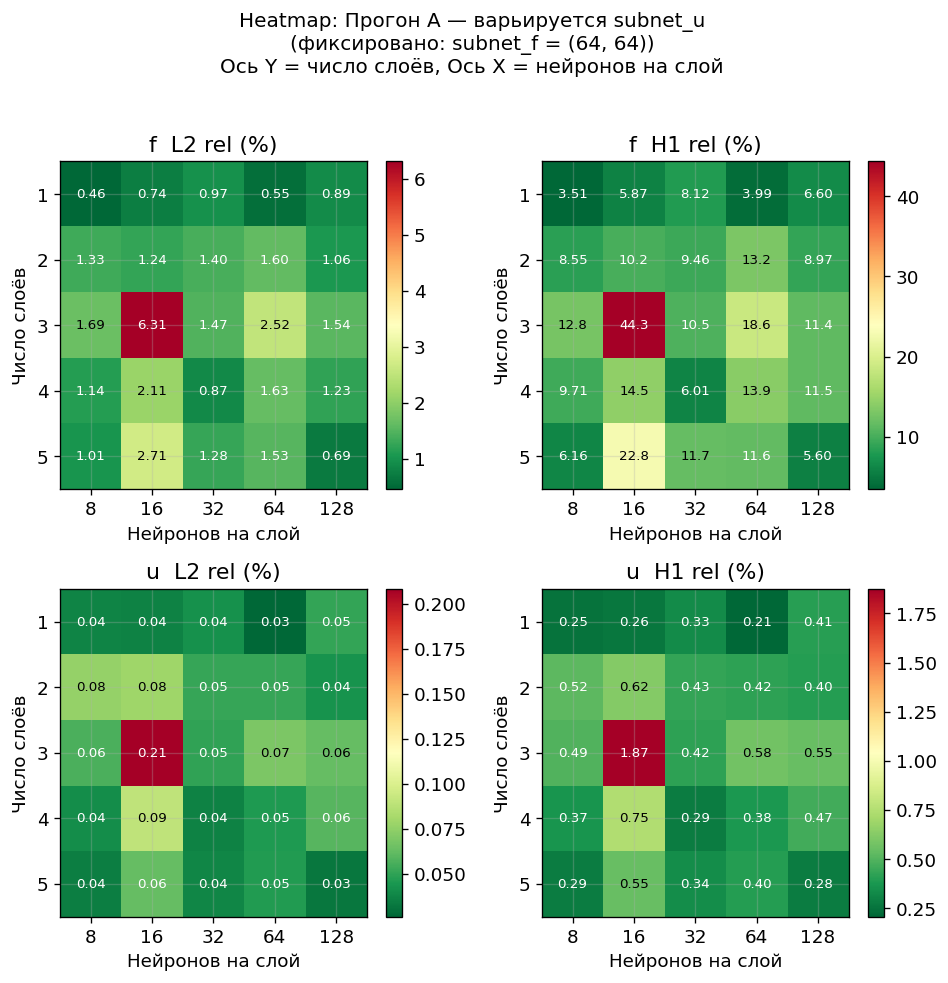

→ D:\PINN_VKR\arch_analysis_3_15\heatmap_Прогон_A_—_варьируется_subnet_u.png


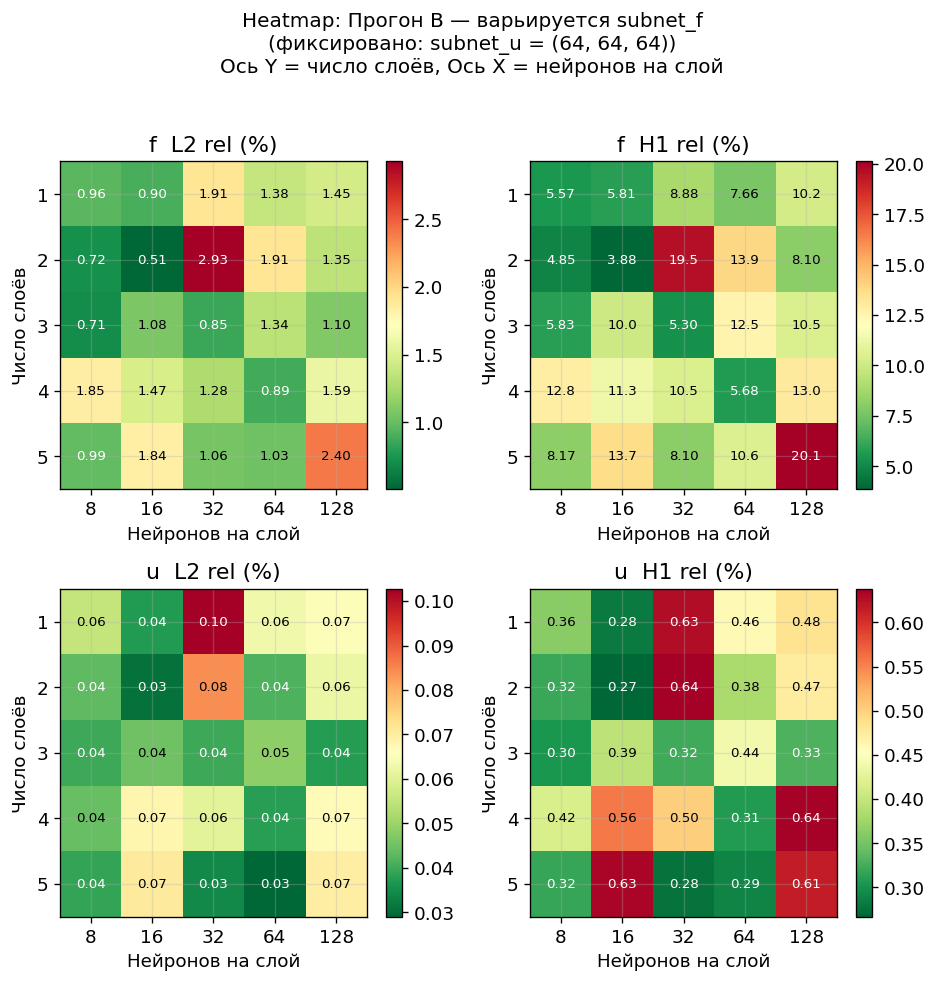

→ D:\PINN_VKR\arch_analysis_3_15\heatmap_Прогон_B_—_варьируется_subnet_f.png


In [ ]:
HM_METRICS = [
    ('f_l2_rel',    'f  L2 rel (%)',   True),
    ('f_h1_rel',    'f  H1 rel (%)',   True),
    ('u_l2_rel',    'u  L2 rel (%)',   True),
    ('u_h1_rel',    'u  H1 rel (%)',   True),
]

def plot_heatmaps(df, run_label, fixed_label, pct_scale_cols=None):
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    fig.suptitle(
        f'Heatmap: {run_label}\n'
        f'(фиксировано: {fixed_label})\n'
        f'Ось Y = число слоёв, Ось X = нейронов на слой',
        fontsize=12, y=1.02
    )

    for ax, (col, title, higher_is_bad) in zip(axes.flat, HM_METRICS):
        # Строим матрицу layers × neurons
        mat = np.full((len(N_LAYERS_LIST), len(N_NEURONS_LIST)), np.nan)
        for i, nl in enumerate(N_LAYERS_LIST):
            for j, nn in enumerate(N_NEURONS_LIST):
                row = df[(df['n_layers'] == nl) & (df['n_neurons'] == nn)]
                if not row.empty:
                    v = row[col].values[0]
                    mat[i, j] = v * 100 if col.endswith('rel') or col.endswith('var') else v

        cmap = 'RdYlGn_r' if higher_is_bad else 'RdYlGn'
        im = ax.imshow(mat, cmap=cmap, aspect='auto')
        plt.colorbar(im, ax=ax)

        ax.set_xticks(range(len(N_NEURONS_LIST)))
        ax.set_xticklabels(N_NEURONS_LIST)
        ax.set_yticks(range(len(N_LAYERS_LIST)))
        ax.set_yticklabels(N_LAYERS_LIST)
        ax.set_xlabel('Нейронов на слой')
        ax.set_ylabel('Число слоёв')
        ax.set_title(title)

        for i in range(len(N_LAYERS_LIST)):
            for j in range(len(N_NEURONS_LIST)):
                v = mat[i, j]
                if not np.isnan(v):
                    txt = f'{v:.2f}' if abs(v) < 10 else f'{v:.1f}'
                    ax.text(j, i, txt, ha='center', va='center',
                            fontsize=8,
                            color='black' if 0.2 < (v - mat.min()) / (np.ptp(mat) + 1e-12) < 0.8
                            else 'white')

    plt.tight_layout()
    safe = run_label.replace(' ', '_').replace(':', '')
    fname = os.path.join(OUT_DIR, f'heatmap_{safe}.png')
    fig.savefig(fname, bbox_inches='tight', dpi=130)
    plt.show()
    print(f'→ {fname}')


plot_heatmaps(df_A,
              run_label   = 'Прогон A — варьируется subnet_u',
              fixed_label = f'subnet_f = {FIXED_F_FOR_A}')

plot_heatmaps(df_B,
              run_label   = 'Прогон B — варьируется subnet_f',
              fixed_label = f'subnet_u = {FIXED_U_FOR_B}')

---
##  Топ-5 лучших и худших

In [ ]:
TOP_METRIC = 'f_l2_rel'
TOP_N = 5
TOP_COLS = ['arch_label','hidden_u','hidden_f','params_u','params_f',
            'f_l2_rel','f_h1_rel','u_l2_rel','u_h1_rel']

for run_label, df_run, fixed_info in [
    ('A (варьируется subnet_u)', df_A, f'subnet_f={FIXED_F_FOR_A}'),
    ('B (варьируется subnet_f)', df_B, f'subnet_u={FIXED_U_FOR_B}'),
]:
    df_sorted = df_run.sort_values(TOP_METRIC)
    best  = df_sorted.head(TOP_N)[TOP_COLS].reset_index(drop=True)
    worst = df_sorted.tail(TOP_N).sort_values(TOP_METRIC, ascending=False)[TOP_COLS].reset_index(drop=True)

    for tbl in [best, worst]:
        for c in ['f_l2_rel','f_h1_rel','u_l2_rel','u_h1_rel']:
            tbl[c] = tbl[c].apply(fmt_pct)


    print(f'\n{"═"*80}')
    print(f'ПРОГОН {run_label}  |  {fixed_info}')
    print(f'  ★ ТОП-{TOP_N} ЛУЧШИХ  (наименьший f_L2):')
    display(best)
    print(f'  ✗ ТОП-{TOP_N} ХУДШИХ  (наибольший f_L2):')
    display(worst)

    rname = run_label[0]
    best.to_csv(os.path.join(OUT_DIR,  f'top5_best_run{rname}.csv'),  index=False)
    worst.to_csv(os.path.join(OUT_DIR, f'top5_worst_run{rname}.csv'), index=False)

print('\n✓ top5_best/worst для A и B сохранены')


════════════════════════════════════════════════════════════════════════════════
ПРОГОН A (варьируется subnet_u)  |  subnet_f=(64, 64)
  ★ ТОП-5 ЛУЧШИХ  (наименьший f_L2):


,arch_label,hidden_u,hidden_f,params_u,params_f,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel
0,L1_N8,"(8,)","(64, 64)",33,4417,0.4565%,3.5050%,0.0376%,0.2471%
1,L1_N64,"(64,)","(64, 64)",257,4417,0.5540%,3.9941%,0.0263%,0.2079%
2,L5_N128,"(128, 128, 128, 128, 128)","(64, 64)",66561,4417,0.6940%,5.5963%,0.0327%,0.2820%
3,L1_N16,"(16,)","(64, 64)",65,4417,0.7365%,5.8740%,0.0370%,0.2611%
4,L4_N32,"(32, 32, 32, 32)","(64, 64)",3297,4417,0.8715%,6.0079%,0.0367%,0.2854%


  ✗ ТОП-5 ХУДШИХ  (наибольший f_L2):


,arch_label,hidden_u,hidden_f,params_u,params_f,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel
0,L3_N16,"(16, 16, 16)","(64, 64)",609,4417,6.3096%,44.3333%,0.2081%,1.8732%
1,L5_N16,"(16, 16, 16, 16, 16)","(64, 64)",1153,4417,2.7123%,22.8107%,0.0626%,0.5525%
2,L3_N64,"(64, 64, 64)","(64, 64)",8577,4417,2.5217%,18.6173%,0.0694%,0.5751%
3,L4_N16,"(16, 16, 16, 16)","(64, 64)",881,4417,2.1097%,14.4909%,0.0902%,0.7476%
4,L3_N8,"(8, 8, 8)","(64, 64)",177,4417,1.6900%,12.7958%,0.0563%,0.4945%



════════════════════════════════════════════════════════════════════════════════
ПРОГОН B (варьируется subnet_f)  |  subnet_u=(64, 64, 64)
  ★ ТОП-5 ЛУЧШИХ  (наименьший f_L2):


,arch_label,hidden_u,hidden_f,params_u,params_f,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel
0,L2_N16,"(64, 64, 64)","(16, 16)",8577,337,0.5092%,3.8767%,0.0307%,0.2667%
1,L3_N8,"(64, 64, 64)","(8, 8, 8)",8577,177,0.7056%,5.8314%,0.0397%,0.3042%
2,L2_N8,"(64, 64, 64)","(8, 8)",8577,105,0.7244%,4.8545%,0.0431%,0.3198%
3,L3_N32,"(64, 64, 64)","(32, 32, 32)",8577,2241,0.8502%,5.2967%,0.0398%,0.3222%
4,L4_N64,"(64, 64, 64)","(64, 64, 64, 64)",8577,12737,0.8855%,5.6759%,0.0377%,0.3074%


  ✗ ТОП-5 ХУДШИХ  (наибольший f_L2):


,arch_label,hidden_u,hidden_f,params_u,params_f,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel
0,L2_N32,"(64, 64, 64)","(32, 32)",8577,1185,2.9272%,19.5433%,0.0840%,0.6378%
1,L5_N128,"(64, 64, 64)","(128, 128, 128, 128, 128)",8577,66561,2.3955%,20.1125%,0.0698%,0.6149%
2,L1_N32,"(64, 64, 64)","(32,)",8577,129,1.9125%,8.8760%,0.1027%,0.6263%
3,L2_N64,"(64, 64, 64)","(64, 64)",8577,4417,1.9075%,13.8799%,0.0416%,0.3824%
4,L4_N8,"(64, 64, 64)","(8, 8, 8, 8)",8577,249,1.8476%,12.8286%,0.0441%,0.4150%



✓ top5_best/worst для A и B сохранены


---
##  Ранжированные барчарты

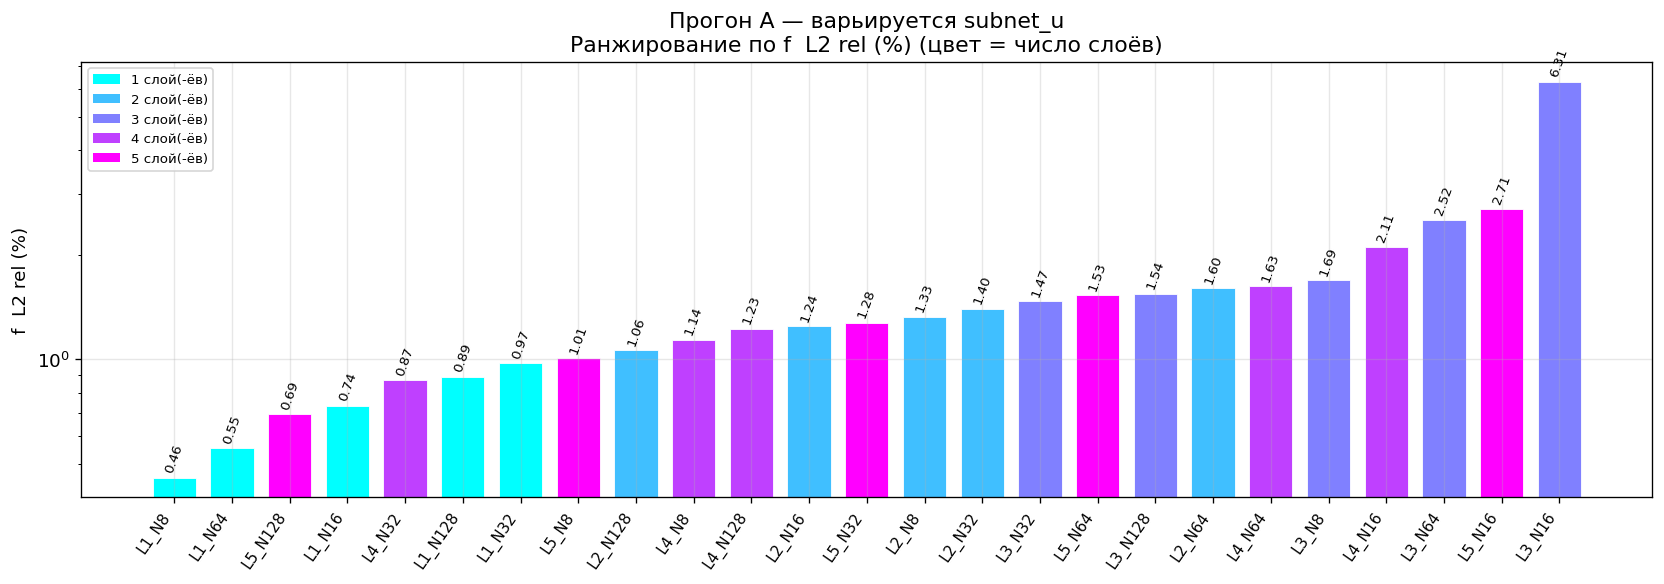

→ D:\PINN_VKR\arch_analysis_3_15\barchart_f_l2_rel_runA.png


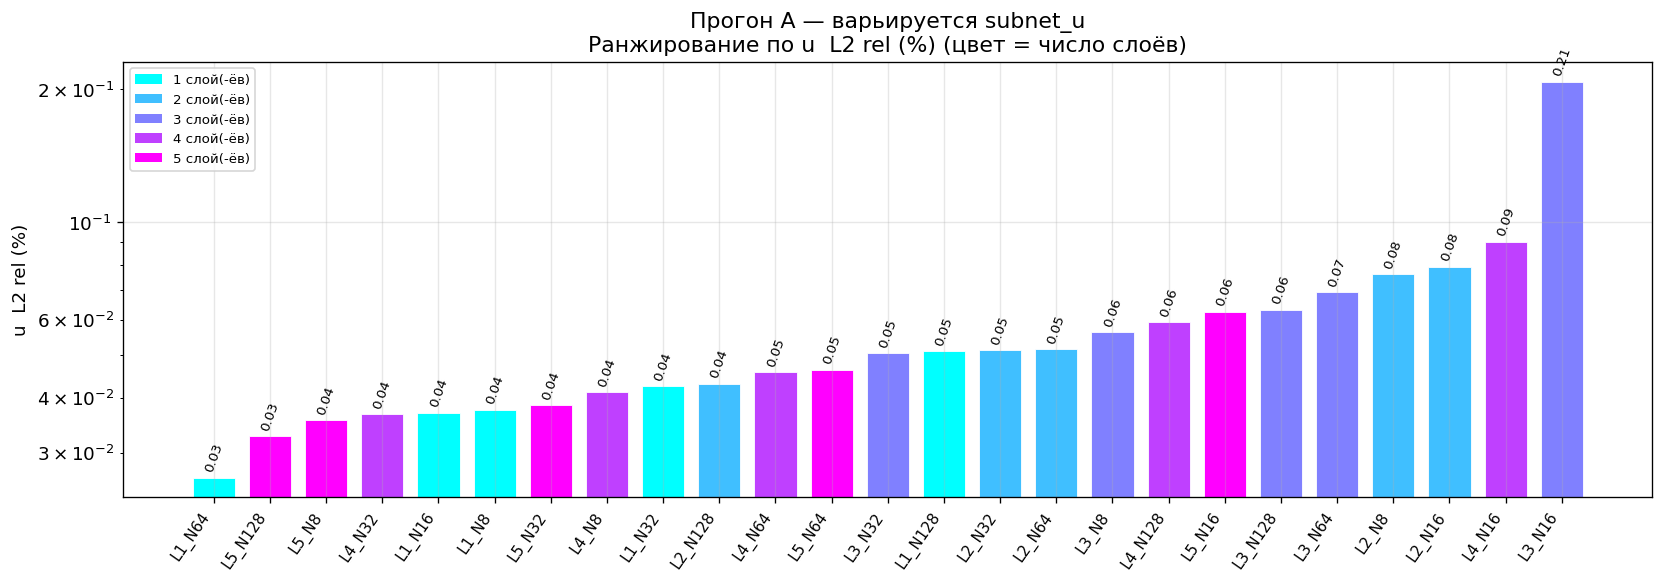

→ D:\PINN_VKR\arch_analysis_3_15\barchart_u_l2_rel_runA.png


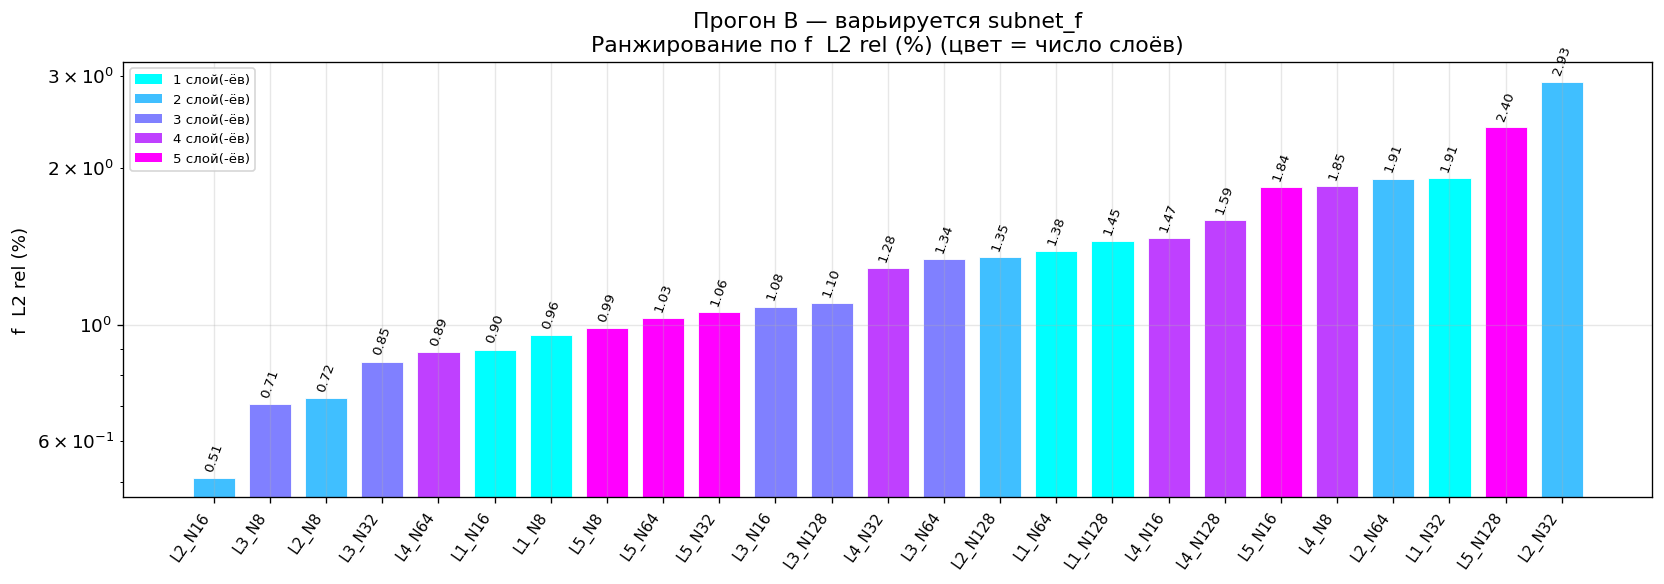

→ D:\PINN_VKR\arch_analysis_3_15\barchart_f_l2_rel_runB.png


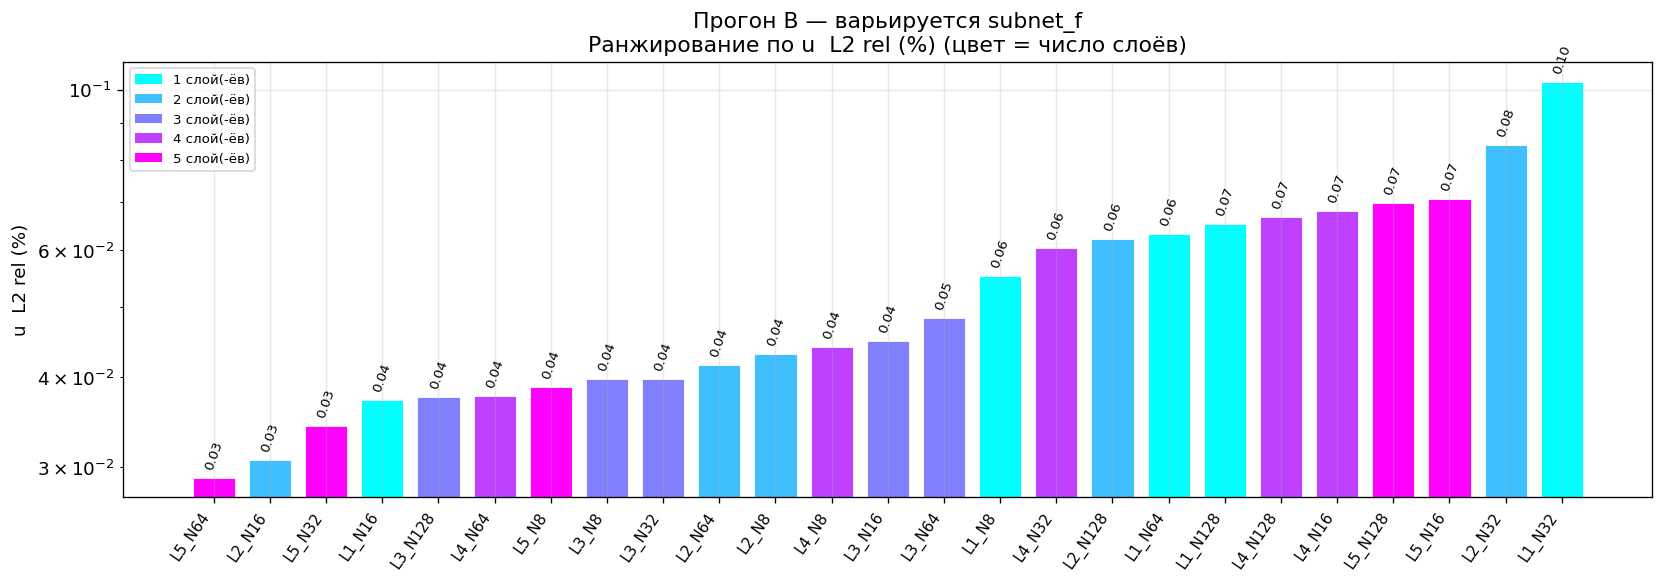

→ D:\PINN_VKR\arch_analysis_3_15\barchart_u_l2_rel_runB.png


In [ ]:
def plot_ranked_bar(df, run_label, metric='f_l2_rel', ylabel='f  L2 rel (%)',
                    color='#1f77b4', fname_suffix='A'):
    df_sorted = df.sort_values(metric).reset_index(drop=True)
    vals  = df_sorted[metric].values * 100
    xlbls = df_sorted['arch_label'].values

    cmap_layers = plt.cm.get_cmap('cool', len(N_LAYERS_LIST))
    bar_colors  = [cmap_layers(df_sorted['n_layers'].values[i] - 1)
                   for i in range(len(df_sorted))]

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(range(len(vals)), vals, color=bar_colors,
                  edgecolor='white', lw=0.5, width=0.75)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{v:.2f}', ha='center', va='bottom',
                fontsize=8, rotation=70)

    ax.set_xticks(range(len(xlbls)))
    ax.set_xticklabels(xlbls, rotation=55, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'Прогон {fname_suffix} — {run_label}\n'
                 f'Ранжирование по {ylabel} (цвет = число слоёв)')
    ax.set_yscale('log')

    from matplotlib.patches import Patch
    legend_elems = [Patch(facecolor=cmap_layers(i), label=f'{i+1} слой(-ёв)')
                    for i in range(len(N_LAYERS_LIST))]
    ax.legend(handles=legend_elems, fontsize=8, loc='upper left')

    plt.tight_layout()
    fname = os.path.join(OUT_DIR, f'barchart_{metric}_run{fname_suffix}.png')
    fig.savefig(fname, bbox_inches='tight', dpi=130)
    plt.show()
    print(f'→ {fname}')


plot_ranked_bar(df_A, 'варьируется subnet_u', 'f_l2_rel', 'f  L2 rel (%)', fname_suffix='A')
plot_ranked_bar(df_A, 'варьируется subnet_u', 'u_l2_rel', 'u  L2 rel (%)', fname_suffix='A')

plot_ranked_bar(df_B, 'варьируется subnet_f', 'f_l2_rel', 'f  L2 rel (%)', fname_suffix='B')
plot_ranked_bar(df_B, 'варьируется subnet_f', 'u_l2_rel', 'u  L2 rel (%)', fname_suffix='B')

---
##  Финальный отчёт

In [32]:
print('\n' + '═'*80)
print('ФИНАЛЬНЫЙ ОТЧЁТ')
print('═'*80)

for run_label, df_run, fixed_info, varied in [
    ('A', df_A, f'subnet_f={FIXED_F_FOR_A}', 'subnet_u'),
    ('B', df_B, f'subnet_u={FIXED_U_FOR_B}', 'subnet_f'),
]:
    best_row  = df_run.loc[df_run['f_l2_rel'].idxmin()]
    worst_row = df_run.loc[df_run['f_l2_rel'].idxmax()]

    print(f'\n── Прогон {run_label}  ({fixed_info}, варьируется {varied}) ──')
    print(f'  Диапазон f_L2:   {df_run["f_l2_rel"].min()*100:.3f}% – {df_run["f_l2_rel"].max()*100:.3f}%')
    print(f'  Диапазон u_L2:   {df_run["u_l2_rel"].min()*100:.3f}% – {df_run["u_l2_rel"].max()*100:.3f}%')
    print(f'  Лучшая конфиг:   {varied}={best_row[f"hidden_{varied[-1]}"]}')
    print(f'    f_L2={best_row["f_l2_rel"]*100:.4f}%  '
          f'u_L2={best_row["u_l2_rel"]*100:.4f}%  ')
    print(f'  Худшая конфиг:   {varied}={worst_row[f"hidden_{varied[-1]}"]}')
    print(f'    f_L2={worst_row["f_l2_rel"]*100:.4f}%  '
          f'u_L2={worst_row["u_l2_rel"]*100:.4f}%')
    print(f'  Разброс f_L2:    {df_run["f_l2_rel"].std()*100:.4f}% (std)')
    print(f'  Кол-во параметров: {df_run["params_" + varied[-1]].min()} – '
          f'{df_run["params_" + varied[-1]].max()}')

print('\n' + '═'*80)
print('Файлы сохранены:')
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f))
    print(f'  {f:<45} {size/1024:.1f} KB')
print(f'\nПапка: {OUT_DIR}')


════════════════════════════════════════════════════════════════════════════════
ФИНАЛЬНЫЙ ОТЧЁТ
════════════════════════════════════════════════════════════════════════════════

── Прогон A  (subnet_f=(64, 64), варьируется subnet_u) ──
  Диапазон f_L2:   0.456% – 6.310%
  Диапазон u_L2:   0.026% – 0.208%
  Лучшая конфиг:   subnet_u=(8,)
    f_L2=0.4565%  u_L2=0.0376%  
  Худшая конфиг:   subnet_u=(16, 16, 16)
    f_L2=6.3096%  u_L2=0.2081%
  Разброс f_L2:    1.1389% (std)
  Кол-во параметров: 33 – 66561

── Прогон B  (subnet_u=(64, 64, 64), варьируется subnet_f) ──
  Диапазон f_L2:   0.509% – 2.927%
  Диапазон u_L2:   0.029% – 0.103%
  Лучшая конфиг:   subnet_f=(16, 16)
    f_L2=0.5092%  u_L2=0.0307%  
  Худшая конфиг:   subnet_f=(32, 32)
    f_L2=2.9272%  u_L2=0.0840%
  Разброс f_L2:    0.5615% (std)
  Кол-во параметров: 33 – 66561

════════════════════════════════════════════════════════════════════════════════
Файлы сохранены:
  barchart_f_l2_rel_runA.png                    72.1 K